In [1]:
# Work with numeric arrays and cell masks.
import numpy as np
# Summarize the query populations in a labeled table.
import pandas as pd

# Open count stores and run Scarf analyses.
import scarf
# Give the reference and query plots descriptive labels.
from scarf.plotting import CellField

# Keep routine logs and progress bars out of the results.
scarf.configure_output(level="WARNING", progress=False)

# Connect to the public example-data repository.
repository = scarf.cytebase.connect("scarf_docs")

# Download the unstimulated reference cells.
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
# Open the reference count store.
ds_ctrl = scarf.DataStore(
    f"{ctrl_path}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)
# Inspect the opened store's cells and features.
ds_ctrl

Downloading bucket files: 73623734 / 73623734 complete

Downloading bytes: 73623734 / 73623734 complete

DataStore has 8486 (8487) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_UMAP1', 'RNA_UMAP2', 
            'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 
            'RNA_percentRibo', 'cluster_labels'
   RNA assay has 35635 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells'

In [2]:
# Download the interferon-stimulated query cells.
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
# Open the query store where mapping results will be saved.
ds_stim = scarf.DataStore(
    f"{stim_path}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)
# Inspect the opened store's cells and features.
ds_stim

Downloading bucket files: 78846023 / 78846023 complete

Downloading bytes: 78846023 / 78846023 complete

DataStore has 10111 (10111) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_UMAP1', 'RNA_UMAP2', 
            'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 
            'RNA_percentRibo', 'cluster_labels'
   RNA assay has 35635 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells'

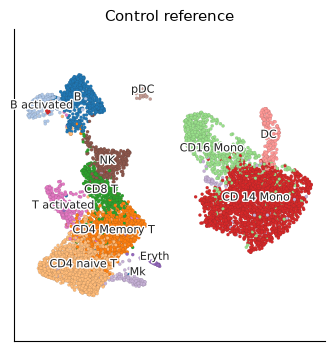

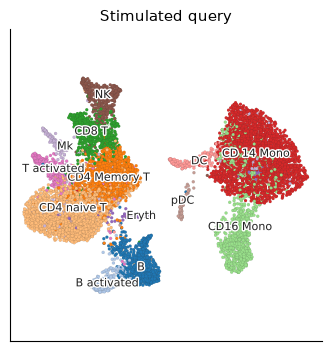

In [3]:
# Inspect the published labels in the control reference.
ds_ctrl.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=CellField("cluster_labels", label="Control reference"),
)
# Inspect the published labels in the stimulated query.
ds_stim.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=CellField("cluster_labels", label="Stimulated query"),
)

In [4]:
# Open the saved analysis and its exact results.
run = ds_ctrl.pipeline.open(label="docs_default")
# Keep the reference UMAP fixed for mapping-score plots.
reference_layout = run["umap"]
# Prepare a reusable reference from the saved neighbors.
reference_ref = ds_ctrl.build_mapping_reference(run["neighbors"])
# Load the saved reference model.
reference = ds_ctrl.get_mapping_reference(reference_ref)
# Inspect the reference saved for future query datasets.
reference_ref

ArtifactRef(assay='RNA', kind='mapping_reference', artifact_id='f707570ab752...')

In [5]:
# Open the saved analysis of the query cells.
query_run = ds_stim.pipeline.open(label="docs_default")
# Keep the query UMAP for displaying transferred labels.
query_layout = query_run["umap"]
# Map the selected query cells onto the fixed reference.
mapping_ref = ds_stim.run_mapping(reference, query_run['analysis_cell_selection'])
# Inspect the saved query-mapping reference.
mapping_ref

ArtifactRef(assay='RNA', kind='projection', artifact_id='81362e0a2b4c...')

In [6]:
# Load the saved mapping and its diagnostics.
mapping = ds_stim.get_mapping_result(mapping_ref, reference=reference)
# Inspect feature coverage and query mapping diagnostics.
mapping.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1,
 'algorithmVariant': 'scaled_pca',
 'uninformativeCellCount': 0,
 'queryScaledDispersion': 1.329895474385472}

In [7]:
# Find the query cell rows included in the saved analysis.
mapped_rows = np.flatnonzero(query_run.cells.fetch_all("I"))
# Read the published labels in mapped-cell order.
query_labels = np.asarray(ds_stim.cells.fetch_all("cluster_labels"))[mapped_rows]
# Use text labels consistently when forming plot groups.
query_labels = query_labels.astype(str)
# Choose a few known populations for separate mapping-score panels.
focus = {"CD 14 Mono", "CD4 Memory T", "CD4 naive T", "NK"}
# Keep the selected populations and group the remaining labels as other.
score_groups = np.array(
    [label if label in focus else "other" for label in query_labels],
    dtype=object,
)
# Count cells in each mapping-score group.
pd.Series(score_groups, name="query population").value_counts().to_frame("cells")

,cells
query population,
other,3462
CD 14 Mono,2532
CD4 naive T,2390
CD4 Memory T,1297
NK,430


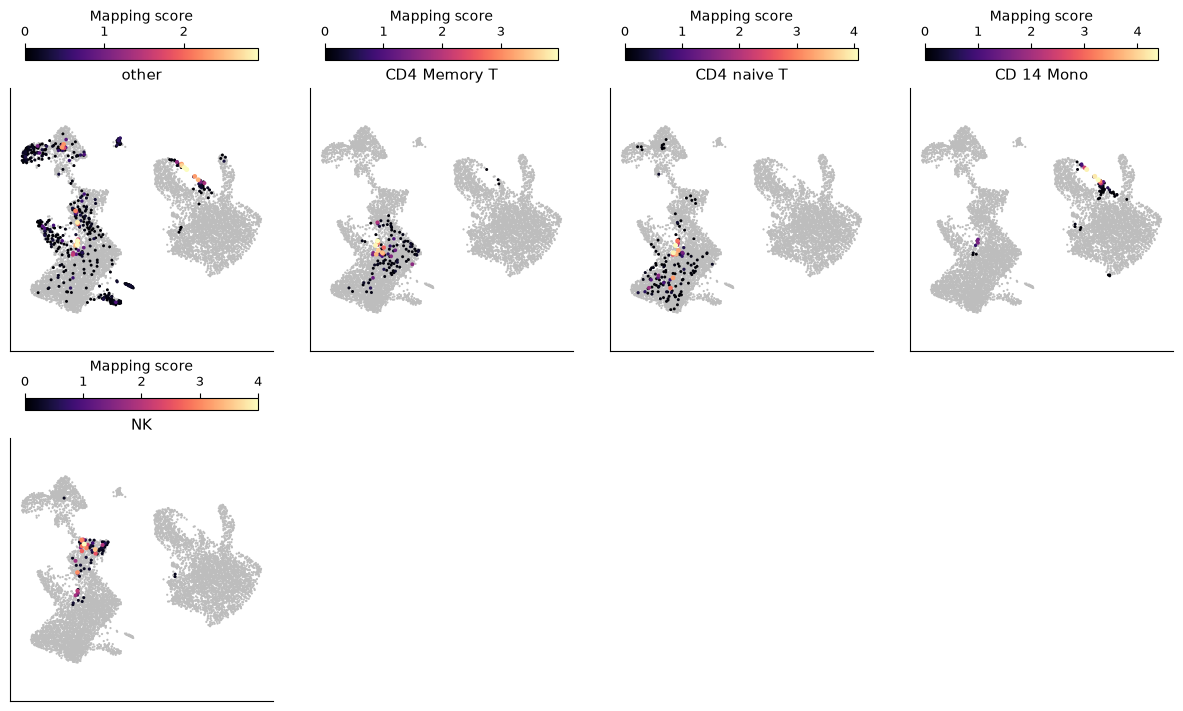

In [8]:
# Show where each query group contributes weight on the reference.
ds_stim.plots.mapping_score(
    mapping_ref,
    reference=reference,
    layout=reference_layout,
    target_groups=score_groups,
    size_by_score=True,
    figsize=(12, 7),
)

In [9]:
# Transfer reference labels with the default abstention threshold.
transfer_ref = ds_stim.run_label_transfer(
    mapping_ref,
    reference=reference,
    reference_labels="cluster_labels",
)
# Load the transferred labels and their supporting evidence.
transfer = ds_stim.get_label_transfer(transfer_ref)
# Count cells in each reported category.
transfer.labels.notna().value_counts().rename(
    index={True: "labelled", False: "abstained"}
).rename("query cells")

label
labelled     9475
abstained     636
Name: query cells, dtype: int64

In [10]:
# Count cells in each reported category.
transfer.evidence["abstentionReason"].value_counts()

abstentionReason
below_threshold    636
Name: count, dtype: int64

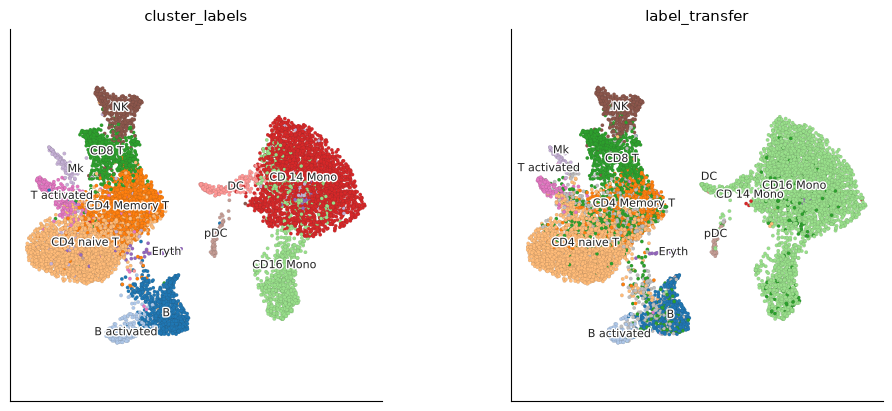

In [11]:
# Compare published and transferred labels on the query UMAP.
ds_stim.plots.embedding(
    layout=query_layout,
    color_by=["cluster_labels", transfer_ref],
    figsize=(10, 4),
)

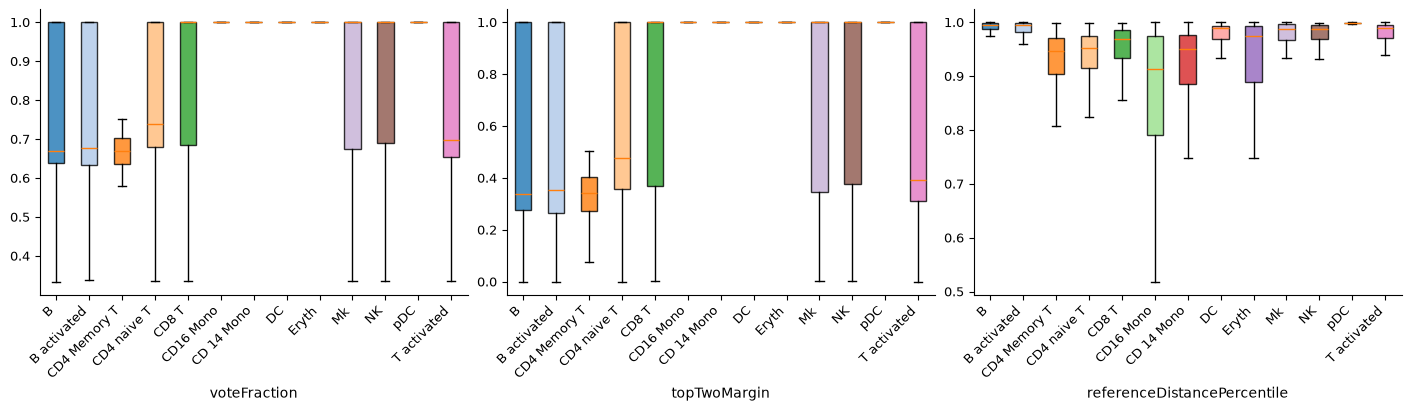

In [12]:
# Inspect the evidence supporting transferred labels.
ds_stim.plots.mapping_evidence(
    transfer_ref,
    target_groups=query_labels,
    metrics=("voteFraction", "topTwoMargin", "referenceDistancePercentile"),
    kind="box",
    figsize=(14, 4),
)

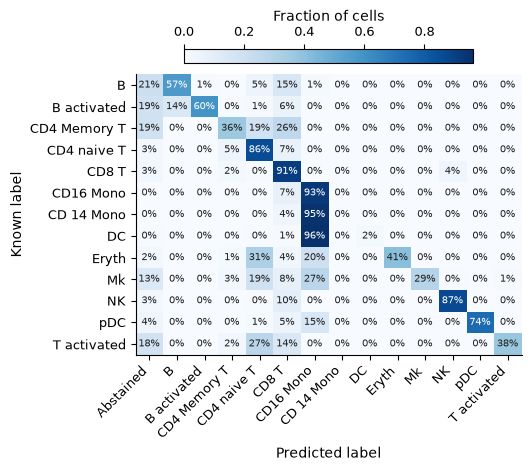

In [13]:
# Compare transferred labels with the known query labels.
ds_stim.plots.mapping_confusion(
    transfer_ref,
    known_labels=query_labels,
    normalize="true",
)

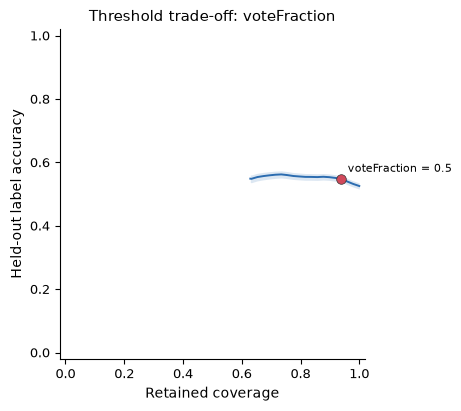

In [14]:
# Compare label accuracy and retained coverage across thresholds.
ds_stim.plots.mapping_calibration(transfer_ref, known_labels=query_labels)

In [15]:
# Load the saved reference model.
reference = ds_ctrl.get_mapping_reference(reference_ref)
# Reload the exact mapping without recomputing it.
reloaded_mapping = ds_stim.get_mapping_result(mapping_ref, reference=reference)
# Reload the saved labels from the query store.
reloaded_transfer = ds_stim.get_label_transfer(transfer_ref)
# Check the reloaded cell count, correction, label source, and threshold.
(
    reloaded_mapping.n_cells,
    reloaded_mapping.correction_method,
    reloaded_transfer.reference_label_source,
    reloaded_transfer.threshold_fraction,
)

(10111, 'none', 'cluster_labels', 0.5)

In [16]:
# Display the saved result and its upstream inputs.
ds_stim.lineage(transfer_ref, references=reference)

```mermaid
flowchart LR
    artifact0["external 76db8b3af9a5 / RNA / metadata_snapshot | snapshot_run_metadata | 06aa908f4cb7"]
    artifact1["external 76db8b3af9a5 / datastore / cell_selection | snapshot_pipeline_input_selection | f28d835c67a6"]
    artifact2["external 76db8b3af9a5 / datastore / metadata_snapshot | snapshot_run_metadata | 90c112e9cc25"]
    artifact3["external 76db8b3af9a5 / datastore / cell_selection | filter_pipeline_cells | ee088b2b3fb5"]
    artifact4["external 76db8b3af9a5 / RNA / feature_summary | summarize_rna_features | 46d42cb66000"]
    artifact5["external 76db8b3af9a5 / RNA / feature_selection | select_hvgs | 4c17c7296871"]
    artifact6["external 76db8b3af9a5 / RNA / normalized | run_normalization | 66d4cb42d7ea"]
    artifact7["external 76db8b3af9a5 / RNA / feature_scaling | calculate_feature_scaling | 6b7c6d54cd20"]
    artifact8["external 76db8b3af9a5 / RNA / reduction | run_pca | d52d4fa4b788"]
    artifact9["external 76db8b3af9a5 / RNA / ann_index | build_ann_index | d64855037574"]
    artifact10["external 76db8b3af9a5 / RNA / neighbors | query_neighbors | 4ecf18b278f3"]
    artifact11["external 76db8b3af9a5 / RNA / mapping_reference | build_mapping_reference | f707570ab752"]
    artifact12["RNA / feature_selection | create_all_features | 783720eb05b2"]
    artifact13["RNA / feature_selection | select_mapping_overlap | 06396025e2a5"]
    artifact14["datastore / cell_selection | snapshot_pipeline_input_selection | bb841a267dc1"]
    artifact15["datastore / metadata_snapshot | snapshot_run_metadata | 38b018b72c0a"]
    artifact16["datastore / cell_selection | filter_pipeline_cells | ddebdef016b6"]
    artifact17["RNA / projection | map_query | 81362e0a2b4c"]
    artifact18["datastore / reference_labels | freeze_reference_labels | 4085861e2b08"]
    artifact19["RNA / label_transfer | transfer_labels | 8227d22398bf | outputs: output"]
    artifact8 -->|"coordinates"| artifact10
    artifact9 -->|"ann_index"| artifact10
    artifact10 -->|"neighbors"| artifact11
    artifact3 -->|"cell_selection"| artifact11
    artifact5 -->|"feature_selection"| artifact11
    artifact8 -->|"reduction"| artifact11
    artifact9 -->|"ann_index"| artifact11
    artifact11 -->|"mapping_reference"| artifact13
    artifact12 -->|"all_features"| artifact13
    artifact14 -->|"input_cell_selection"| artifact16
    artifact15 -->|"cell_snapshot"| artifact16
    artifact11 -->|"mapping_reference"| artifact17
    artifact13 -->|"feature_selection"| artifact17
    artifact16 -->|"cell_selection"| artifact17
    artifact11 -->|"mapping_reference"| artifact18
    artifact16 -->|"cell_selection"| artifact19
    artifact17 -->|"projection"| artifact19
    artifact18 -->|"reference_labels"| artifact19
    artifact1 -->|"input_cell_selection"| artifact3
    artifact2 -->|"cell_snapshot"| artifact3
    artifact3 -->|"cell_selection"| artifact4
    artifact0 -->|"feature_snapshot"| artifact5
    artifact4 -->|"feature_summary"| artifact5
    artifact3 -->|"cell_selection"| artifact6
    artifact5 -->|"feature_selection"| artifact6
    artifact6 -->|"normalized"| artifact7
    artifact3 -->|"pca_cell_selection"| artifact8
    artifact6 -->|"normalized"| artifact8
    artifact7 -->|"feature_scaling"| artifact8
    artifact8 -->|"coordinates"| artifact9
```

### Artifact details

#### external 76db8b3af9a5 / RNA / metadata_snapshot / 06aa908f4cb7
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `RNA/artifacts/metadata_snapshot/06aa908f4cb787481f0a18acadb419573e83f92279ddf5c396064d5b7ef0f4b8`
- Operation: `snapshot_run_metadata`
- Parameters: `assay="RNA"; axis="feature"; ordered_columns=["names"]`
- Other inputs: `column_fingerprints={"names":"3c305b573cceda002d35561b73018ef57f9c278161a4acf65e887722647f9400"}; ordered_row_ids_fingerprint="302a7e844bccbbf99c3735c6ba0c78d82a90c6dcd530d180da66bdf25b7ea12c"`

#### external 76db8b3af9a5 / datastore / cell_selection / f28d835c67a6
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `artifacts/cell_selection/f28d835c67a67a9127925e51bc134433503ad2f430e14873393b2ea2ffb8d86b`
- Operation: `snapshot_pipeline_input_selection`
- Parameters: `assay="RNA"`
- Execution options: `source_column="I"`
- Other inputs: `ordered_row_ids_fingerprint="b8ae1c59ec631b0c048dd2175616a5673a5b6004d1da425d4e82ae8eed85c9eb"; values_fingerprint="942289374bb784305e7aec1ca445d56349ee61a66cefed83b8e064e78eb59055"`

#### external 76db8b3af9a5 / datastore / metadata_snapshot / 90c112e9cc25
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `artifacts/metadata_snapshot/90c112e9cc25d585baf5a66302e1be686087d3269e325577b5a106b2a44582a7`
- Operation: `snapshot_run_metadata`
- Parameters: `assay=null; axis="cell"; ordered_columns=["names","RNA_nCounts","RNA_nFeatures"]`
- Other inputs: `column_fingerprints={"RNA_nCounts":"181fe2181bc1d8d1463938a7be0ffc36d9a9c6bbc4ccd6b949ea88850859ead3","RNA_nFeatures":"59a20d2ca21b2f155f1c4f52b1bb73d5a85dda0368ac6d377852b8864c...; ordered_row_ids_fingerprint="b8ae1c59ec631b0c048dd2175616a5673a5b6004d1da425d4e82ae8eed85c9eb"`

#### external 76db8b3af9a5 / datastore / cell_selection / ee088b2b3fb5
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `artifacts/cell_selection/ee088b2b3fb532da4329544ad656172b22fd744f7d093ba31556344d42456aef`
- Operation: `filter_pipeline_cells`
- Parameters: `attrs=["RNA_nCounts","RNA_nFeatures"]; enabled=true; highs=[15000,4000]; keepBounds=false; lows=[500,200]; method="manual"`
- Execution options: `source_column="I"`
- Other inputs: `ordered_row_ids_fingerprint="b8ae1c59ec631b0c048dd2175616a5673a5b6004d1da425d4e82ae8eed85c9eb"; values_fingerprint="57c174616ae4017ee75e9877e3092407317191997dcdf54edc62782d7bb6290d"`

#### external 76db8b3af9a5 / RNA / feature_summary / 46d42cb66000
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `RNA/artifacts/feature_summary/46d42cb66000fb214cd53e04df256e7d759cf92a9aa4d5b5dd2c534778fba1c0`
- Operation: `summarize_rna_features`
- Parameters: `normalization_method={"module":"scarf.assay","qualname":"norm_lib_size"}; size_factor=1000`
- Execution options: `nthreads=2`
- Other inputs: `dataset_fingerprint="76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6"`

#### external 76db8b3af9a5 / RNA / feature_selection / 4c17c7296871
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `RNA/artifacts/feature_selection/4c17c72968716af8c6f2e0d26b3a788c901c2781b813aabb79f76503ebcf4835`
- Operation: `select_hvgs`
- Parameters: `bin_strategy="adaptive"; blacklist="^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$"; blacklist_fingerprint="be3ebd2369dc4732cca36bdc525c57669e1fa039a95d0827768ff09a84097ce8"; keep_bounds=false; lowess_frac=0.1; max_cells=8466; max_mean={"special_float":"inf"}; max_var={"special_float":"inf"}; min_cells=20; min_mean={"special_float":"-inf"}; min_var={"special_float":"-inf"}; n_bins=200; ... 3 more`
- Execution options: `invalidate_cache=false; nthreads=2; plot_kwargs={}; show_plot=false`

#### external 76db8b3af9a5 / RNA / normalized / 66d4cb42d7ea
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `RNA/artifacts/normalized/66d4cb42d7ea883bd6f3df34ee165b200cad64b729d1d4dbc646e524a0dffe02`
- Operation: `run_normalization`
- Parameters: `log_transform=true; normalization_method={"external_hook":true,"module":"scarf.assay","qualname":"norm_lib_size"}; renormalize_subset=true; size_factor=1000.0`
- Execution options: `invalidate_cache=false`
- Other inputs: `dataset_fingerprint="76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6"`

#### external 76db8b3af9a5 / RNA / feature_scaling / 6b7c6d54cd20
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `RNA/artifacts/feature_scaling/6b7c6d54cd20a9212252e1d853c0ef28db417dbc519020cfb73f2987c8615f7a`
- Operation: `calculate_feature_scaling`
- Parameters: `enabled=true`
- Execution options: `batch_size=8486; invalidate_cache=false; local_cache="auto"`

#### external 76db8b3af9a5 / RNA / reduction / d52d4fa4b788
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `RNA/artifacts/reduction/d52d4fa4b788b9feac2bd804eb50ae0aa38a65f4fdd7de9b68406f66cd81378e`
- Operation: `run_pca`
- Parameters: `dims=25; feat_scaling=true`
- Execution options: `batch_size=8486; invalidate_cache=false; local_cache="auto"; show_elbow_plot=false`

#### external 76db8b3af9a5 / RNA / ann_index / d64855037574
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `RNA/artifacts/ann_index/d648550375740c4f717e649755921a3d24a6621487ad044ef7afb5411beaba55`
- Operation: `build_ann_index`
- Parameters: `ann_ef=50; ann_efc=50; ann_m=48; ann_metric="l2"; ann_parallel=false; parallel_threads=null; rand_state=4466`
- Execution options: `batch_size=8486; invalidate_cache=false`

#### external 76db8b3af9a5 / RNA / neighbors / 4ecf18b278f3
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `RNA/artifacts/neighbors/4ecf18b278f39ef26b9ab90e517afb90a896fa16ce0ff9bbea481276ab4fd2a1`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=21`
- Execution options: `batch_size=8486; invalidate_cache=false`

#### external 76db8b3af9a5 / RNA / mapping_reference / f707570ab752
- Status: `complete`
- Dataset fingerprint: `76db8b3af9a5dc39b83287d9f72634d0fb20b01820a4c14b4c02d164cc0fa6e6`
- Path: `RNA/artifacts/mapping_reference/f707570ab7526b7b5773f309534eaf982676a5c403779c80c00609ee0f468b52`
- Operation: `build_mapping_reference`
- Parameters: `method="pca"`

#### RNA / feature_selection / 783720eb05b2
- Status: `complete`
- Path: `RNA/artifacts/feature_selection/783720eb05b2cbcafa77cf130848d316132c8e15b12c8362ff2497257a2baec2`
- Operation: `create_all_features`
- Parameters: `dataset_fingerprint="964bdc16af53845ed5a223e569b2b04fe610e7e63d2c9de30d3aa22d39ba381f"; ordered_feature_ids_fingerprint="302a7e844bccbbf99c3735c6ba0c78d82a90c6dcd530d180da66bdf25b7ea12c"`

#### RNA / feature_selection / 06396025e2a5
- Status: `complete`
- Path: `RNA/artifacts/feature_selection/06396025e2a598feaec85b60a9aa428e5b6f0e3dad49468aa23a728e86b542a1`
- Operation: `select_mapping_overlap`

#### datastore / cell_selection / bb841a267dc1
- Status: `complete`
- Path: `artifacts/cell_selection/bb841a267dc105177694c065a8f39c7d1d806985f3f64c794f34029a69489fac`
- Operation: `snapshot_pipeline_input_selection`
- Parameters: `assay="RNA"`
- Execution options: `source_column="I"`
- Other inputs: `ordered_row_ids_fingerprint="e114c7b8b5d093b8aab13d20228a07adfed90c590ce062911fe7e36d44299639"; values_fingerprint="f1a838aea6bc106bdf54b63bd8a25627be80078afb3635a5785fb659e7ecbcb9"`

#### datastore / metadata_snapshot / 38b018b72c0a
- Status: `complete`
- Path: `artifacts/metadata_snapshot/38b018b72c0ae0f46fea3addad9bca95c4ab2827223b0789932d64b53af7134a`
- Operation: `snapshot_run_metadata`
- Parameters: `assay=null; axis="cell"; ordered_columns=["names","RNA_nCounts","RNA_nFeatures"]`
- Other inputs: `column_fingerprints={"RNA_nCounts":"94829386bbddf7838049f68e2a72b692f80f8c631155a126bd1d1195809d9c49","RNA_nFeatures":"d3ea8bed13dd12a0a1f15657574a06975ee23ae4568e398d4cdb1d2332...; ordered_row_ids_fingerprint="e114c7b8b5d093b8aab13d20228a07adfed90c590ce062911fe7e36d44299639"`

#### datastore / cell_selection / ddebdef016b6
- Status: `complete`
- Path: `artifacts/cell_selection/ddebdef016b600ceda9804f7a67eb2cf7ce0f00c13f21233cfcebaac7efa4965`
- Operation: `filter_pipeline_cells`
- Parameters: `attrs=["RNA_nCounts","RNA_nFeatures"]; enabled=true; highs=[15000,4000]; keepBounds=false; lows=[500,200]; method="manual"`
- Execution options: `source_column="I"`
- Other inputs: `ordered_row_ids_fingerprint="e114c7b8b5d093b8aab13d20228a07adfed90c590ce062911fe7e36d44299639"; values_fingerprint="f1a838aea6bc106bdf54b63bd8a25627be80078afb3635a5785fb659e7ecbcb9"`

#### RNA / projection / 81362e0a2b4c
- Status: `complete`
- Path: `RNA/artifacts/projection/81362e0a2b4cabebad8fd67fbbecfdf56a1fe51b30ea9a9a6598df44c3433586`
- Operation: `map_query`
- Parameters: `correction_method="none"; missing_feature_policy="reference_mean"; save_k=3`
- Other inputs: `query_batch_count=1; query_batch_fingerprint="0c645c9799dae57a3819dea9efdd7c4bb82fdfc318f713fd65d324ebc2066bb3"; query_dataset_fingerprint="964bdc16af53845ed5a223e569b2b04fe610e7e63d2c9de30d3aa22d39ba381f"`

#### datastore / reference_labels / 4085861e2b08
- Status: `complete`
- Path: `artifacts/reference_labels/4085861e2b086e4b88a8e31ba08c492a1b607b04f29fb8868d6130acac125abd`
- Operation: `freeze_reference_labels`
- Parameters: `source_column="cluster_labels"`
- Other inputs: `labels_fingerprint="f0633ce969585e6248b81923efaad68d189ffc7ca6bdfe1d2405f0209a63dfeb"`

#### RNA / label_transfer / 8227d22398bf
- Status: `complete`
- Path: `RNA/artifacts/label_transfer/8227d22398bf590238b968230c2ae21a35bf98c24be3263f2a53377d8b483aa0`
- Operation: `transfer_labels`
- Outputs: `output`
- Parameters: `algorithm_version=1; max_distance=null; threshold_fraction=0.5`